# Lab 2: Learning When Labels Are Scarce

**Semi-supervised network intrusion detection on CICIDS2017/CICIDS2018**

This notebook implements the complete experiment requested in the lab sheet:

- a full-label upper baseline;
- few-label lower baselines at **1%, 5%, and 10%**;
- iterative **pseudo-labelling**;
- **co-training** as the second semi-supervised method;
- a confidence-threshold ablation on the validation set only;
- accuracy, macro-F1, attack recall, ROC-AUC, and false-alarm rate (FAR);
- a report-ready table and macro-F1 curve.

The defaults are tuned for an Intel Core i5-12500H and an RTX 4060 Laptop GPU. The notebook probes an optional CUDA XGBoost installation and otherwise uses a fast, portable scikit-learn histogram model. Data are stored as `float32`, predictions are batched, pseudo-label growth is capped, and CPU thread counts are bounded to avoid oversubscription.

> **Important:** when no CICIDS files are present, `DATA_MODE="auto"` uses a small synthetic dataset so every cell can be smoke-tested. Synthetic results are not valid for submission. Put your exact Lab 1 splits in `data/train.csv`, `data/validation.csv`, and `data/test.csv` (or use `data/lab1_splits.npz`) and run all cells again.

## 1. Environment and reproducibility

Run this cell before importing NumPy or scikit-learn. Twelve worker threads match the i5-12500H's physical-core count while leaving the operating system responsive. Change `CPU_THREADS` only if your laptop becomes thermally constrained.

In [1]:
import os
from pathlib import Path

SEED = 42
CPU_THREADS = min(12, os.cpu_count() or 4)
for variable in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(variable, str(CPU_THREADS))
os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")

import gc
import json
import platform
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.datasets import make_classification
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from threadpoolctl import threadpool_limits

np.random.seed(SEED)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | pandas {pd.__version__}")
print(f"Detected {os.cpu_count()} logical CPUs; using at most {CPU_THREADS} numerical-library threads")
print(f"Platform: {platform.platform()}")

Python 3.11.9 | scikit-learn 1.9.0 | pandas 3.0.5
Detected 16 logical CPUs; using at most 12 numerical-library threads
Platform: Windows-10-10.0.26200-SP0


## 2. Configuration

`auto` chooses the first available source in this order: exact Lab 1 `.npz` splits, exact Lab 1 CSV splits, raw CICIDS CSV files, then synthetic smoke-test data.

For the fairest Lab 1 comparison, use pre-split files. An `.npz` file must contain `X_train`, `y_train`, `X_val`, `y_val`, `X_test`, and `y_test`; `feature_names` is optional. CSV files should contain the target column in every split.

In [2]:
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "lab2_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_MODE = "auto"  # "auto", "npz", "presplit_csv", "raw_csv", or "synthetic"
NPZ_SPLITS = DATA_DIR / "lab1_splits.npz"
TRAIN_CSV = DATA_DIR / "train.csv"
VALIDATION_CSV = DATA_DIR / "validation.csv"
TEST_CSV = DATA_DIR / "test.csv"
RAW_CSV_GLOB = "*.csv"
LABEL_COLUMN = "Label"

# Remove identifiers and timestamps that do not represent traffic behaviour.
DROP_COLUMNS = {
    "Flow ID", "Source IP", "Destination IP", "Src IP", "Dst IP", "Timestamp"
}
BENIGN_TEXT_LABELS = {"BENIGN", "NORMAL", "NORMAL TRAFFIC"}
BENIGN_NUMERIC_LABEL = 0

# Memory-conscious defaults for a typical 16 GB laptop. Keep MAX_TEST_ROWS=None
# to evaluate on the exact, fully labelled Lab 1 test set.
MAX_TRAIN_ROWS = 3_000_000
MAX_VALIDATION_ROWS = 1_000_000
MAX_TEST_ROWS = None
MAX_RAW_ROWS = 3_000_000
CSV_CHUNK_ROWS = 1_000_000

BUDGETS = (0.01, 0.05, 0.10)
SEEDS = (42,)  # Use (42, 43, 44) for a stronger final report if runtime permits.
CONFIDENCE_THRESHOLD = 0.95
ABLATION_THRESHOLDS = (0.90, 0.95, 0.99)
SSL_ROUNDS = 2
PSEUDO_WEIGHT = 0.50
PSEUDO_TO_TRUE_RATIO_PER_ROUND = 1.0
MAX_PSEUDO_PER_CLASS_PER_ROUND = 1_000_000
PREDICTION_BATCH_SIZE = 65_536
RUN_ABLATION = True

# "auto" probes CUDA XGBoost, "sklearn" always uses the CPU fallback,
# and "xgboost_cuda" requires a working CUDA-enabled XGBoost installation.
MODEL_BACKEND = "auto"
XGB_ESTIMATORS = 180
HGB_ITERATIONS = 120

# Paste all five metrics from Lab 1 here to use the original upper baseline,
# otherwise the notebook retrains a full-label model on the working train set.
LAB1_FULL_METRICS = None
# Example only:
# LAB1_FULL_METRICS = {"accuracy": 0.99, "macro_f1": 0.96,
#                      "recall": 0.94, "roc_auc": 0.99, "far": 0.01}

SYNTHETIC_ROWS = 6_000
SYNTHETIC_FEATURES = 30
TEST_FRACTION = 0.20
VALIDATION_FRACTION = 0.20

print("Configuration loaded. Random seed:", SEED)

Configuration loaded. Random seed: 42


## 3. Data loading and CICIDS cleaning

CSVs are read in chunks. When a row cap is active, random-priority reservoir sampling keeps a reproducible sample without loading the complete source into memory. Cleaning is fitted on the training schema only, then applied identically to validation and test data.

In [3]:
def _clean_column_names(frame):
    frame = frame.copy()
    frame.columns = [str(column).strip() for column in frame.columns]
    return frame.loc[:, ~frame.columns.duplicated()].copy()


def _canonical_name(name):
    return "".join(character.lower() for character in str(name) if character.isalnum())


def _find_label_column(frame, requested=LABEL_COLUMN):
    by_name = {_canonical_name(column): column for column in frame.columns}
    for candidate in (requested, "Label", "Class", "Target", "Attack"):
        match = by_name.get(_canonical_name(candidate))
        if match is not None:
            return match
    raise ValueError(
        f"Could not find a target column. Set LABEL_COLUMN; available columns begin with {list(frame.columns[:12])}."
    )


def _load_csv_reservoir(paths, max_rows, seed):
    paths = [Path(path) for path in paths]
    if not paths:
        raise FileNotFoundError("No CSV files matched the configured path(s).")

    rng = np.random.default_rng(seed)
    reservoir = None
    priorities = None
    all_chunks = []
    seen = 0

    for path in paths:
        for chunk in pd.read_csv(path, chunksize=CSV_CHUNK_ROWS, low_memory=False):
            chunk = _clean_column_names(chunk)
            seen += len(chunk)
            if max_rows is None:
                all_chunks.append(chunk)
                continue

            chunk_priorities = rng.random(len(chunk))
            if reservoir is None:
                reservoir = chunk.reset_index(drop=True)
                priorities = chunk_priorities
            else:
                reservoir = pd.concat([reservoir, chunk], ignore_index=True, sort=False)
                priorities = np.concatenate([priorities, chunk_priorities])

            if len(reservoir) > max_rows:
                keep = np.argpartition(priorities, max_rows - 1)[:max_rows]
                reservoir = reservoir.iloc[keep].reset_index(drop=True)
                priorities = priorities[keep]

    result = pd.concat(all_chunks, ignore_index=True, sort=False) if max_rows is None else reservoir
    if result is None or result.empty:
        raise ValueError("The configured CSV input contains no rows.")
    print(f"Loaded {len(result):,} of {seen:,} rows from {len(paths)} CSV file(s).")
    return result.reset_index(drop=True)


def _encode_binary_target(series):
    numeric = pd.to_numeric(series, errors="coerce")
    unique_numeric = set(numeric.dropna().unique().tolist())
    if numeric.notna().all() and unique_numeric and unique_numeric.issubset({0, 1}):
        return (numeric.astype(np.int8) != BENIGN_NUMERIC_LABEL).astype(np.int8).to_numpy()

    normalised = series.astype(str).str.strip().str.upper()
    benign = normalised.isin({label.upper() for label in BENIGN_TEXT_LABELS})
    if not benign.any():
        examples = normalised.value_counts().head(10).to_dict()
        raise ValueError(
            "No benign labels were recognised. Update BENIGN_TEXT_LABELS. "
            f"Most frequent labels: {examples}"
        )
    return (~benign).astype(np.int8).to_numpy()


def _clean_and_align(train_frame, validation_frame, test_frame):
    frames = [_clean_column_names(frame) for frame in (train_frame, validation_frame, test_frame)]
    label_columns = [_find_label_column(frame) for frame in frames]
    targets = [_encode_binary_target(frame[label]) for frame, label in zip(frames, label_columns)]

    drop_names = {_canonical_name(column) for column in DROP_COLUMNS}
    feature_frames = []
    for frame, label in zip(frames, label_columns):
        kept = [
            column for column in frame.columns
            if column != label and _canonical_name(column) not in drop_names
        ]
        feature_frames.append(frame[kept])

    validation_columns = set(feature_frames[1].columns)
    test_columns = set(feature_frames[2].columns)
    common = [
        column for column in feature_frames[0].columns
        if column in validation_columns and column in test_columns
    ]
    if not common:
        raise ValueError("The train, validation, and test files have no common feature columns.")

    numeric_frames = []
    for frame in feature_frames:
        numeric = frame[common].apply(pd.to_numeric, errors="coerce")
        numeric = numeric.replace([np.inf, -np.inf], np.nan)
        numeric_frames.append(numeric)

    train_numeric = numeric_frames[0]
    valid_fraction = train_numeric.notna().mean()
    varying = train_numeric.nunique(dropna=True) > 1
    usable = [column for column in common if valid_fraction[column] >= 0.50 and varying[column]]
    if len(usable) < 2:
        raise ValueError("Fewer than two usable numeric features remain after cleaning.")

    arrays = [
        np.ascontiguousarray(frame[usable].to_numpy(dtype=np.float32, na_value=np.nan))
        for frame in numeric_frames
    ]
    print(f"Kept {len(usable)} numeric, non-constant features; dropped {len(common) - len(usable)} unusable columns.")
    return (*arrays, *targets, np.asarray(usable, dtype=object))


def _resolve_data_mode():
    valid_modes = {"auto", "npz", "presplit_csv", "raw_csv", "synthetic"}
    if DATA_MODE not in valid_modes:
        raise ValueError(f"DATA_MODE must be one of {sorted(valid_modes)}")
    if DATA_MODE != "auto":
        return DATA_MODE
    if NPZ_SPLITS.exists():
        return "npz"
    if TRAIN_CSV.exists() and VALIDATION_CSV.exists() and TEST_CSV.exists():
        return "presplit_csv"
    raw_paths = [path for path in DATA_DIR.glob(RAW_CSV_GLOB) if path.is_file()]
    if raw_paths:
        return "raw_csv"
    return "synthetic"


def load_data():
    mode = _resolve_data_mode()
    print("Resolved data mode:", mode)

    if mode == "npz":
        data = np.load(NPZ_SPLITS, allow_pickle=False)
        required = {"X_train", "y_train", "X_val", "y_val", "X_test", "y_test"}
        missing = required.difference(data.files)
        if missing:
            raise KeyError(f"{NPZ_SPLITS} is missing arrays: {sorted(missing)}")
        X_train = np.ascontiguousarray(data["X_train"], dtype=np.float32)
        X_val = np.ascontiguousarray(data["X_val"], dtype=np.float32)
        X_test = np.ascontiguousarray(data["X_test"], dtype=np.float32)
        y_train = np.asarray(data["y_train"], dtype=np.int8).reshape(-1)
        y_val = np.asarray(data["y_val"], dtype=np.int8).reshape(-1)
        y_test = np.asarray(data["y_test"], dtype=np.int8).reshape(-1)
        feature_names = np.asarray(
            [f"feature_{index}" for index in range(X_train.shape[1])], dtype=object
        )
        if "feature_names" in data.files:
            try:
                feature_names = np.asarray(data["feature_names"], dtype=object)
            except ValueError:
                print("Feature names require pickled objects; using generated safe names instead.")
        return X_train, X_val, X_test, y_train, y_val, y_test, feature_names, mode

    if mode == "presplit_csv":
        train = _load_csv_reservoir([TRAIN_CSV], MAX_TRAIN_ROWS, SEED)
        validation = _load_csv_reservoir([VALIDATION_CSV], MAX_VALIDATION_ROWS, SEED + 1)
        test = _load_csv_reservoir([TEST_CSV], MAX_TEST_ROWS, SEED + 2)
        values = _clean_and_align(train, validation, test)
        return (*values, mode)

    if mode == "raw_csv":
        excluded = {TRAIN_CSV.resolve(), VALIDATION_CSV.resolve(), TEST_CSV.resolve()}
        raw_paths = sorted(
            path for path in DATA_DIR.glob(RAW_CSV_GLOB)
            if path.is_file() and path.resolve() not in excluded
        )
        raw = _load_csv_reservoir(raw_paths, MAX_RAW_ROWS, SEED)
        label = _find_label_column(raw)
        stratify_target = _encode_binary_target(raw[label])
        train_validation, test = train_test_split(
            raw, test_size=TEST_FRACTION, stratify=stratify_target, random_state=SEED
        )
        train_validation_target = _encode_binary_target(train_validation[_find_label_column(train_validation)])
        relative_validation = VALIDATION_FRACTION / (1.0 - TEST_FRACTION)
        train, validation = train_test_split(
            train_validation,
            test_size=relative_validation,
            stratify=train_validation_target,
            random_state=SEED,
        )
        print("WARNING: raw_csv mode creates a new split. Use exact Lab 1 splits for a direct Lab 1 comparison.")
        values = _clean_and_align(train, validation, test)
        return (*values, mode)

    X, y = make_classification(
        n_samples=SYNTHETIC_ROWS,
        n_features=SYNTHETIC_FEATURES,
        n_informative=18,
        n_redundant=6,
        n_clusters_per_class=2,
        weights=[0.78, 0.22],
        class_sep=1.8,
        flip_y=0.012,
        random_state=SEED,
    )
    X = np.asarray(X, dtype=np.float32)
    X_train_validation, X_test, y_train_validation, y_test = train_test_split(
        X, y, test_size=TEST_FRACTION, stratify=y, random_state=SEED
    )
    relative_validation = VALIDATION_FRACTION / (1.0 - TEST_FRACTION)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_validation,
        y_train_validation,
        test_size=relative_validation,
        stratify=y_train_validation,
        random_state=SEED,
    )
    feature_names = np.asarray([f"synthetic_feature_{index:02d}" for index in range(X.shape[1])], dtype=object)
    print("WARNING: synthetic data are for execution testing only, not for the submitted experiment.")
    return (
        np.ascontiguousarray(X_train), np.ascontiguousarray(X_val), np.ascontiguousarray(X_test),
        np.asarray(y_train, dtype=np.int8), np.asarray(y_val, dtype=np.int8), np.asarray(y_test, dtype=np.int8),
        feature_names, mode,
    )

In [4]:
X_train, X_val, X_test, y_train, y_val, y_test, feature_names, ACTIVE_DATA_MODE = load_data()

for name, X_part, y_part in (
    ("train", X_train, y_train), ("validation", X_val, y_val), ("test", X_test, y_test)
):
    if len(X_part) != len(y_part):
        raise AssertionError(f"{name} feature and target lengths differ")
    if X_part.ndim != 2 or X_part.shape[1] != X_train.shape[1]:
        raise AssertionError(f"{name} feature matrix has an incompatible shape")
    if set(np.unique(y_part)) != {0, 1}:
        raise AssertionError(f"{name} must contain both binary classes 0 and 1")

split_summary = pd.DataFrame(
    {
        "rows": [len(y_train), len(y_val), len(y_test)],
        "features": [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
        "benign": [(y_train == 0).sum(), (y_val == 0).sum(), (y_test == 0).sum()],
        "attack": [(y_train == 1).sum(), (y_val == 1).sum(), (y_test == 1).sum()],
        "attack_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)
memory_mb = sum(array.nbytes for array in (X_train, X_val, X_test)) / (1024 ** 2)
print(split_summary.to_string(float_format=lambda value: f"{value:.4f}"))
print(f"Feature-array memory: {memory_mb:.1f} MiB ({X_train.dtype})")

Resolved data mode: raw_csv
Loaded 2,830,743 of 2,830,743 rows from 8 CSV file(s).
Kept 70 numeric, non-constant features; dropped 8 unusable columns.
               rows  features   benign  attack  attack_rate
train       1698445        70  1363857  334588       0.1970
validation   566149        70   454620  111529       0.1970
test         566149        70   454620  111529       0.1970
Feature-array memory: 755.9 MiB (float32)


## 4. Hardware-aware model backend

The probe trains only four rows. A missing/old/non-CUDA XGBoost build falls back cleanly to `HistGradientBoostingClassifier`. The same resolved backend is used by every method, so the comparison remains fair.

In [5]:
def _probe_xgboost_cuda():
    try:
        import xgboost as xgb
        from xgboost import XGBClassifier
    except Exception as error:
        return False, f"XGBoost unavailable ({type(error).__name__})"

    try:
        major_version = int(str(xgb.__version__).split(".")[0])
        if major_version < 2:
            return False, f"XGBoost {xgb.__version__} is too old for device='cuda'"
        build_info = xgb.build_info() if hasattr(xgb, "build_info") else {}
        cuda_flag = build_info.get("USE_CUDA") if build_info else None
        if isinstance(cuda_flag, str):
            cuda_flag = cuda_flag.strip().lower() in {"1", "on", "true", "yes"}
        if cuda_flag is False:
            return False, f"XGBoost {xgb.__version__} was built without CUDA"

        probe_X = np.asarray([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
        probe_y = np.asarray([0, 0, 1, 1], dtype=np.int8)
        probe = XGBClassifier(
            n_estimators=2,
            max_depth=1,
            tree_method="hist",
            device="cuda",
            eval_metric="logloss",
            verbosity=0,
            random_state=SEED,
        )
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            probe.fit(probe_X, probe_y)
        config = probe.get_booster().save_config().replace(" ", "")
        if '"device":"cuda' not in config:
            return False, f"XGBoost {xgb.__version__} did not select a CUDA device"
        return True, f"XGBoost {xgb.__version__} with CUDA"
    except Exception as error:
        return False, f"CUDA probe failed ({type(error).__name__}: {error})"


if MODEL_BACKEND == "sklearn":
    ACTIVE_BACKEND = "sklearn"
    BACKEND_NOTE = "CPU backend explicitly requested"
elif MODEL_BACKEND in {"auto", "xgboost_cuda"}:
    cuda_ok, BACKEND_NOTE = _probe_xgboost_cuda()
    if MODEL_BACKEND == "xgboost_cuda" and not cuda_ok:
        raise RuntimeError(BACKEND_NOTE)
    ACTIVE_BACKEND = "xgboost_cuda" if cuda_ok else "sklearn"
else:
    raise ValueError("MODEL_BACKEND must be 'auto', 'sklearn', or 'xgboost_cuda'.")

print(f"Active model backend: {ACTIVE_BACKEND} ({BACKEND_NOTE})")


def make_estimator(seed):
    if ACTIVE_BACKEND == "xgboost_cuda":
        from xgboost import XGBClassifier
        return XGBClassifier(
            n_estimators=XGB_ESTIMATORS,
            max_depth=8,
            learning_rate=0.08,
            min_child_weight=2,
            subsample=0.90,
            colsample_bytree=0.90,
            reg_lambda=1.0,
            tree_method="hist",
            device="cuda",
            eval_metric="logloss",
            n_jobs=max(1, min(4, CPU_THREADS // 2)),
            random_state=seed,
            verbosity=0,
        )
    return HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=HGB_ITERATIONS,
        max_leaf_nodes=31,
        min_samples_leaf=5,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=10,
        random_state=seed,
    )


def fit_estimator(X, y, seed, trust_weights=None):
    y = np.asarray(y, dtype=np.int8)
    if np.unique(y).size != 2:
        raise ValueError("Every fitted subset must contain both benign and attack samples.")
    balanced = compute_sample_weight(class_weight="balanced", y=y).astype(np.float32)
    if trust_weights is not None:
        balanced *= np.asarray(trust_weights, dtype=np.float32)
    balanced /= balanced.mean()
    model = make_estimator(seed)
    with threadpool_limits(limits=CPU_THREADS):
        model.fit(X, y, sample_weight=balanced)
    return model


def predict_proba_batched(model, X, batch_size=PREDICTION_BATCH_SIZE):
    batches = []
    for start in range(0, len(X), batch_size):
        batch = np.asarray(model.predict_proba(X[start:start + batch_size]), dtype=np.float32)
        batches.append(batch)
    return np.concatenate(batches, axis=0)


def predict_proba_indexed(model, X, row_indices, feature_indices=None, batch_size=PREDICTION_BATCH_SIZE):
    # Predict selected rows without first copying the complete unlabelled pool.
    batches = []
    for start in range(0, len(row_indices), batch_size):
        rows = row_indices[start:start + batch_size]
        batch = X[rows] if feature_indices is None else X[np.ix_(rows, feature_indices)]
        batches.append(np.asarray(model.predict_proba(batch), dtype=np.float32))
    return np.concatenate(batches, axis=0)

Active model backend: xgboost_cuda (XGBoost 3.2.0 with CUDA)


## 5. Metrics and label-budget splits

Class `0` is benign and class `1` is attack. Therefore attack recall is $TP/(TP+FN)$, while false-alarm rate is $FP/(FP+TN)$. The stratified splitter hides labels only inside the training set; validation and test labels never enter fitting.

In [6]:
METRIC_COLUMNS = ["accuracy", "macro_f1", "recall", "roc_auc", "far"]


def evaluate_model(model, X, y):
    probability = predict_proba_batched(model, X)
    prediction = np.argmax(probability, axis=1).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(y, prediction, labels=[0, 1]).ravel()
    far = fp / (fp + tn) if (fp + tn) else np.nan
    auc = roc_auc_score(y, probability[:, 1]) if np.unique(y).size == 2 else np.nan
    return {
        "accuracy": accuracy_score(y, prediction),
        "macro_f1": f1_score(y, prediction, average="macro", zero_division=0),
        "recall": recall_score(y, prediction, pos_label=1, zero_division=0),
        "roc_auc": auc,
        "far": far,
    }


def make_label_budget_split(y, budget, seed):
    requested = max(int(round(len(y) * budget)), 4 * np.unique(y).size)
    if requested >= len(y):
        raise ValueError("The label budget leaves no unlabelled pool.")
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=requested, random_state=seed)
    labelled, unlabelled = next(splitter.split(np.zeros(len(y)), y))
    if np.intersect1d(labelled, unlabelled).size:
        raise AssertionError("Labelled and unlabelled indices overlap.")
    if len(labelled) + len(unlabelled) != len(y):
        raise AssertionError("The budget split does not cover the training set.")
    return labelled.astype(np.int64), unlabelled.astype(np.int64)


def choose_confident(probability, threshold, per_class_cap):
    prediction = np.argmax(probability, axis=1).astype(np.int8)
    confidence = np.max(probability, axis=1)
    chosen = []
    for class_id in (0, 1):
        positions = np.flatnonzero((prediction == class_id) & (confidence >= threshold))
        if len(positions) > per_class_cap:
            local = np.argpartition(confidence[positions], -per_class_cap)[-per_class_cap:]
            positions = positions[local]
        chosen.extend(positions.tolist())
    if not chosen:
        return (
            np.empty(0, dtype=np.int64),
            np.empty(0, dtype=np.int8),
            np.empty(0, dtype=np.float32),
        )
    chosen = np.asarray(chosen, dtype=np.int64)
    chosen = chosen[np.argsort(-confidence[chosen])]
    return chosen, prediction[chosen], confidence[chosen]

## 6. Required method: iterative pseudo-labelling

At each round, the current model labels the remaining unlabelled pool. Only predictions at or above the fixed confidence cutoff are retained. A per-class cap prevents confident benign predictions from overwhelming the scarce attacks, and pseudo-labels receive half the weight of genuine labels. The hidden ground-truth labels are never inspected by this function.

In [7]:
def train_pseudo_labeller(
    X,
    y,
    labelled_indices,
    unlabelled_indices,
    seed,
    threshold=CONFIDENCE_THRESHOLD,
    initial_model=None,
):
    fit_indices = labelled_indices.copy()
    fit_targets = y[labelled_indices].copy()
    trust = np.ones(len(fit_indices), dtype=np.float32)
    remaining = unlabelled_indices.copy()
    model = initial_model
    history = []
    total_added = 0

    per_class_cap = min(
        MAX_PSEUDO_PER_CLASS_PER_ROUND,
        max(1, int(np.ceil(len(labelled_indices) * PSEUDO_TO_TRUE_RATIO_PER_ROUND / 2))),
    )

    for round_index in range(SSL_ROUNDS):
        if model is None or round_index > 0:
            model = fit_estimator(X[fit_indices], fit_targets, seed + round_index, trust)

        probability = predict_proba_indexed(model, X, remaining)
        positions, pseudo_targets, confidence = choose_confident(
            probability, threshold, per_class_cap
        )
        selected = remaining[positions]
        class_counts = np.bincount(pseudo_targets, minlength=2) if len(selected) else np.zeros(2, dtype=int)
        history.append(
            {
                "round": round_index + 1,
                "remaining_before": len(remaining),
                "accepted": len(selected),
                "accepted_benign": int(class_counts[0]),
                "accepted_attack": int(class_counts[1]),
                "mean_confidence": float(confidence.mean()) if len(confidence) else np.nan,
            }
        )
        if len(selected) == 0:
            break

        fit_indices = np.concatenate([fit_indices, selected])
        fit_targets = np.concatenate([fit_targets, pseudo_targets])
        trust = np.concatenate(
            [trust, np.full(len(selected), PSEUDO_WEIGHT, dtype=np.float32)]
        )
        keep = np.ones(len(remaining), dtype=bool)
        keep[positions] = False
        remaining = remaining[keep]
        total_added += len(selected)

        if len(remaining) == 0:
            break

    if total_added:
        model = fit_estimator(X[fit_indices], fit_targets, seed + SSL_ROUNDS, trust)
    return model, pd.DataFrame(history), total_added

## 7. Second method: co-training

Features are deterministically shuffled and divided into two non-overlapping views. Each learner teaches only the other learner. If both learners choose the same row but disagree, that row is rejected. Final probabilities are the average of the two views.

In [8]:
class CoTrainingEnsemble:
    def __init__(self, model_a, model_b, view_a, view_b):
        self.model_a = model_a
        self.model_b = model_b
        self.view_a = np.asarray(view_a, dtype=np.int64)
        self.view_b = np.asarray(view_b, dtype=np.int64)
        self.classes_ = np.asarray([0, 1], dtype=np.int8)

    def predict_proba(self, X):
        probability_a = np.asarray(self.model_a.predict_proba(X[:, self.view_a]), dtype=np.float32)
        probability_b = np.asarray(self.model_b.predict_proba(X[:, self.view_b]), dtype=np.float32)
        return (probability_a + probability_b) / 2.0


def make_feature_views(n_features, seed):
    if n_features < 2:
        raise ValueError("Co-training needs at least two features.")
    permutation = np.random.default_rng(seed).permutation(n_features)
    midpoint = (n_features + 1) // 2
    return np.sort(permutation[:midpoint]), np.sort(permutation[midpoint:])


def train_co_trainer(X, y, labelled_indices, unlabelled_indices, seed, threshold=CONFIDENCE_THRESHOLD):
    view_a, view_b = make_feature_views(X.shape[1], seed)
    indices_a = labelled_indices.copy()
    indices_b = labelled_indices.copy()
    targets_a = y[labelled_indices].copy()
    targets_b = y[labelled_indices].copy()
    trust_a = np.ones(len(indices_a), dtype=np.float32)
    trust_b = np.ones(len(indices_b), dtype=np.float32)
    remaining = unlabelled_indices.copy()
    history = []
    total_unique_added = 0
    model_a = model_b = None
    added_after_fit = False

    per_class_cap = min(
        MAX_PSEUDO_PER_CLASS_PER_ROUND,
        max(1, int(np.ceil(len(labelled_indices) * PSEUDO_TO_TRUE_RATIO_PER_ROUND / 2))),
    )

    for round_index in range(SSL_ROUNDS):
        model_a = fit_estimator(X[np.ix_(indices_a, view_a)], targets_a, seed + 10 * round_index, trust_a)
        model_b = fit_estimator(X[np.ix_(indices_b, view_b)], targets_b, seed + 10 * round_index + 1, trust_b)
        added_after_fit = False

        probability_a = predict_proba_indexed(model_a, X, remaining, view_a)
        probability_b = predict_proba_indexed(model_b, X, remaining, view_b)
        positions_a, labels_a, confidence_a = choose_confident(probability_a, threshold, per_class_cap)
        positions_b, labels_b, confidence_b = choose_confident(probability_b, threshold, per_class_cap)

        proposals_a = {int(position): int(label) for position, label in zip(positions_a, labels_a)}
        proposals_b = {int(position): int(label) for position, label in zip(positions_b, labels_b)}
        conflicts = {
            position for position in proposals_a.keys() & proposals_b.keys()
            if proposals_a[position] != proposals_b[position]
        }
        accepted_a_positions = np.asarray(
            [position for position in positions_a if int(position) not in conflicts], dtype=np.int64
        )
        accepted_b_positions = np.asarray(
            [position for position in positions_b if int(position) not in conflicts], dtype=np.int64
        )

        # A teaches B; B teaches A.
        if len(accepted_b_positions):
            taught_indices = remaining[accepted_b_positions]
            taught_labels = np.asarray([proposals_b[int(position)] for position in accepted_b_positions], dtype=np.int8)
            indices_a = np.concatenate([indices_a, taught_indices])
            targets_a = np.concatenate([targets_a, taught_labels])
            trust_a = np.concatenate(
                [trust_a, np.full(len(taught_indices), PSEUDO_WEIGHT, dtype=np.float32)]
            )
        if len(accepted_a_positions):
            taught_indices = remaining[accepted_a_positions]
            taught_labels = np.asarray([proposals_a[int(position)] for position in accepted_a_positions], dtype=np.int8)
            indices_b = np.concatenate([indices_b, taught_indices])
            targets_b = np.concatenate([targets_b, taught_labels])
            trust_b = np.concatenate(
                [trust_b, np.full(len(taught_indices), PSEUDO_WEIGHT, dtype=np.float32)]
            )

        accepted_union = np.union1d(accepted_a_positions, accepted_b_positions)
        history.append(
            {
                "round": round_index + 1,
                "remaining_before": len(remaining),
                "learner_a_proposals": len(positions_a),
                "learner_b_proposals": len(positions_b),
                "conflicts_rejected": len(conflicts),
                "accepted_unique": len(accepted_union),
                "mean_confidence_a": float(confidence_a.mean()) if len(confidence_a) else np.nan,
                "mean_confidence_b": float(confidence_b.mean()) if len(confidence_b) else np.nan,
            }
        )
        if len(accepted_union) == 0:
            break

        keep = np.ones(len(remaining), dtype=bool)
        keep[accepted_union] = False
        remaining = remaining[keep]
        total_unique_added += len(accepted_union)
        added_after_fit = True
        if len(remaining) == 0:
            break

    if added_after_fit:
        model_a = fit_estimator(X[np.ix_(indices_a, view_a)], targets_a, seed + 10_000, trust_a)
        model_b = fit_estimator(X[np.ix_(indices_b, view_b)], targets_b, seed + 10_001, trust_b)
    ensemble = CoTrainingEnsemble(model_a, model_b, view_a, view_b)
    return ensemble, pd.DataFrame(history), total_unique_added

## 8. Baselines

The full-label model is the upper line. If `LAB1_FULL_METRICS` is supplied, those original Lab 1 numbers are preserved instead of retraining. The budget-specific few-label models below are the lower line that SSL must beat.

In [9]:
result_rows = []
full_metrics_by_seed = {}
few_model_cache = {}
split_cache = {}
ssl_histories = {}

if LAB1_FULL_METRICS is not None:
    missing = set(METRIC_COLUMNS).difference(LAB1_FULL_METRICS)
    if missing:
        raise KeyError(f"LAB1_FULL_METRICS is missing {sorted(missing)}")
    for seed in SEEDS:
        metrics = {metric: float(LAB1_FULL_METRICS[metric]) for metric in METRIC_COLUMNS}
        full_metrics_by_seed[seed] = metrics
        result_rows.append(
            {"seed": seed, "budget_pct": 100.0, "method": "Full-label upper baseline",
             "true_labels": len(y_train), "pseudo_labels": 0, "runtime_s": 0.0, **metrics}
        )
    print("Using the supplied Lab 1 full-label metrics as the upper baseline.")
else:
    if ACTIVE_DATA_MODE == "presplit_csv" and MAX_TRAIN_ROWS is not None:
        print("NOTE: the retrained upper baseline uses the capped working train sample. Paste Lab 1 metrics above for the exact upper line.")
    for seed in SEEDS:
        started = time.perf_counter()
        full_model = fit_estimator(X_train, y_train, seed)
        metrics = evaluate_model(full_model, X_test, y_test)
        elapsed = time.perf_counter() - started
        full_metrics_by_seed[seed] = metrics
        result_rows.append(
            {"seed": seed, "budget_pct": 100.0, "method": "Full-label upper baseline",
             "true_labels": len(y_train), "pseudo_labels": 0, "runtime_s": elapsed, **metrics}
        )
        print(f"Full-label seed {seed}: macro-F1={metrics['macro_f1']:.4f}, FAR={metrics['far']:.4f}, {elapsed:.1f}s")
        del full_model
        gc.collect()

Full-label seed 42: macro-F1=0.9986, FAR=0.0011, 9.3s


## 9. Few-label, pseudo-labelling, and co-training runs

Every method receives exactly the same labelled/unlabelled split for a given budget and seed. Hyperparameters and the confidence cutoff are fixed before test evaluation.

In [10]:
for seed in SEEDS:
    for budget in BUDGETS:
        labelled, unlabelled = make_label_budget_split(y_train, budget, seed)
        split_cache[(seed, budget)] = (labelled, unlabelled)
        actual_budget = 100.0 * len(labelled) / len(y_train)
        print(f"\nSeed {seed} | requested {100 * budget:.0f}% | actual {actual_budget:.3f}% ({len(labelled):,} true labels)")

        started = time.perf_counter()
        few_model = fit_estimator(X_train[labelled], y_train[labelled], seed)
        metrics = evaluate_model(few_model, X_test, y_test)
        elapsed = time.perf_counter() - started
        few_model_cache[(seed, budget)] = few_model
        result_rows.append(
            {"seed": seed, "budget_pct": 100 * budget, "method": "Few-label lower baseline",
             "true_labels": len(labelled), "pseudo_labels": 0, "runtime_s": elapsed, **metrics}
        )
        print(f"  Few-label : macro-F1={metrics['macro_f1']:.4f}, FAR={metrics['far']:.4f}, {elapsed:.1f}s")

        started = time.perf_counter()
        pseudo_model, pseudo_history, pseudo_count = train_pseudo_labeller(
            X_train, y_train, labelled, unlabelled, seed,
            threshold=CONFIDENCE_THRESHOLD, initial_model=few_model,
        )
        metrics = evaluate_model(pseudo_model, X_test, y_test)
        elapsed = time.perf_counter() - started
        ssl_histories[(seed, budget, "Pseudo-labelling")] = pseudo_history
        result_rows.append(
            {"seed": seed, "budget_pct": 100 * budget, "method": "Pseudo-labelling",
             "true_labels": len(labelled), "pseudo_labels": pseudo_count, "runtime_s": elapsed, **metrics}
        )
        print(f"  Pseudo     : macro-F1={metrics['macro_f1']:.4f}, FAR={metrics['far']:.4f}, +{pseudo_count:,} pseudo, {elapsed:.1f}s")
        del pseudo_model
        gc.collect()

        started = time.perf_counter()
        co_model, co_history, co_count = train_co_trainer(
            X_train, y_train, labelled, unlabelled, seed, threshold=CONFIDENCE_THRESHOLD
        )
        metrics = evaluate_model(co_model, X_test, y_test)
        elapsed = time.perf_counter() - started
        ssl_histories[(seed, budget, "Co-training")] = co_history
        result_rows.append(
            {"seed": seed, "budget_pct": 100 * budget, "method": "Co-training",
             "true_labels": len(labelled), "pseudo_labels": co_count, "runtime_s": elapsed, **metrics}
        )
        print(f"  Co-training: macro-F1={metrics['macro_f1']:.4f}, FAR={metrics['far']:.4f}, +{co_count:,} pseudo, {elapsed:.1f}s")
        del co_model
        gc.collect()


Seed 42 | requested 1% | actual 1.000% (16,984 true labels)
  Few-label : macro-F1=0.9969, FAR=0.0016, 2.1s
  Pseudo     : macro-F1=0.9965, FAR=0.0012, +33,968 pseudo, 9.5s
  Co-training: macro-F1=0.9958, FAR=0.0009, +62,430 pseudo, 12.9s

Seed 42 | requested 5% | actual 5.000% (84,922 true labels)
  Few-label : macro-F1=0.9983, FAR=0.0010, 2.5s
  Pseudo     : macro-F1=0.9983, FAR=0.0008, +169,844 pseudo, 10.8s
  Co-training: macro-F1=0.9978, FAR=0.0006, +281,778 pseudo, 15.3s

Seed 42 | requested 10% | actual 10.000% (169,844 true labels)
  Few-label : macro-F1=0.9984, FAR=0.0011, 2.8s
  Pseudo     : macro-F1=0.9985, FAR=0.0009, +339,688 pseudo, 11.8s
  Co-training: macro-F1=0.9982, FAR=0.0007, +507,822 pseudo, 16.6s


## 10. Main results table

**Table 1.** Test-set performance by label budget. Values are means over the configured seeds; macro-F1 standard deviation is included when repeated seeds are used. `macro_f1_gain` is measured against the same-budget few-label lower baseline.

In [11]:
raw_results = pd.DataFrame(result_rows)
aggregation = {metric: "mean" for metric in METRIC_COLUMNS}
aggregation.update({"true_labels": "mean", "pseudo_labels": "mean", "runtime_s": "mean"})
results = raw_results.groupby(["budget_pct", "method"], as_index=False).agg(aggregation)
f1_std = (
    raw_results.groupby(["budget_pct", "method"])["macro_f1"]
    .std(ddof=0)
    .rename("macro_f1_std")
    .reset_index()
)
results = results.merge(f1_std, on=["budget_pct", "method"], how="left")

lower = (
    results[results["method"] == "Few-label lower baseline"]
    .set_index("budget_pct")["macro_f1"]
)
results["macro_f1_gain"] = results.apply(
    lambda row: row["macro_f1"] - lower.get(row["budget_pct"], np.nan)
    if row["method"] in {"Pseudo-labelling", "Co-training"} else np.nan,
    axis=1,
)

method_order = {
    "Few-label lower baseline": 0,
    "Pseudo-labelling": 1,
    "Co-training": 2,
    "Full-label upper baseline": 3,
}
results["_order"] = results["method"].map(method_order)
results = results.sort_values(["budget_pct", "_order"]).drop(columns="_order").reset_index(drop=True)

display_columns = [
    "budget_pct", "method", "true_labels", "pseudo_labels",
    "accuracy", "macro_f1", "macro_f1_std", "macro_f1_gain",
    "recall", "roc_auc", "far", "runtime_s",
]
print(results[display_columns].to_string(index=False, float_format=lambda value: f"{value:.4f}"))
raw_results.to_csv(OUTPUT_DIR / "lab2_results_raw.csv", index=False)
results.to_csv(OUTPUT_DIR / "lab2_results_summary.csv", index=False)
print(f"\nSaved result tables in {OUTPUT_DIR}")

 budget_pct                    method  true_labels  pseudo_labels  accuracy  macro_f1  macro_f1_std  macro_f1_gain  recall  roc_auc    far  runtime_s
     1.0000  Few-label lower baseline   16984.0000         0.0000    0.9980    0.9969        0.0000            NaN  0.9962   0.9999 0.0016     2.1311
     1.0000          Pseudo-labelling   16984.0000     33968.0000    0.9978    0.9965        0.0000        -0.0003  0.9936   0.9999 0.0012     9.5106
     1.0000               Co-training   16984.0000     62430.0000    0.9974    0.9958        0.0000        -0.0010  0.9903   0.9997 0.0009    12.8842
     5.0000  Few-label lower baseline   84922.0000         0.0000    0.9989    0.9983        0.0000            NaN  0.9984   0.9999 0.0010     2.5094
     5.0000          Pseudo-labelling   84922.0000    169844.0000    0.9989    0.9983        0.0000        -0.0000  0.9977   0.9999 0.0008    10.7780
     5.0000               Co-training   84922.0000    281778.0000    0.9986    0.9978        0.0000 

## 11. Change-one-thing experiment: confidence cutoff

Only the pseudo-label confidence threshold changes. The labelled rows, unlabelled pool, base model, training rounds, pseudo-label weight, and cap are held fixed. This ablation is evaluated on **validation**, not test, so it does not leak test information.

**Table 2.** Five-percent-label validation performance before pseudo-labelling and after each threshold.

In [12]:
ablation_results = pd.DataFrame()
if RUN_ABLATION:
    ablation_seed = SEEDS[0]
    ablation_budget = 0.05
    labelled, unlabelled = split_cache.get(
        (ablation_seed, ablation_budget),
        make_label_budget_split(y_train, ablation_budget, ablation_seed),
    )
    base_model = few_model_cache.get((ablation_seed, ablation_budget))
    if base_model is None:
        base_model = fit_estimator(X_train[labelled], y_train[labelled], ablation_seed)
    base_metrics = evaluate_model(base_model, X_val, y_val)

    rows = [
        {"setting": "Before: few-label baseline", "threshold": np.nan,
         "pseudo_labels": 0, **base_metrics}
    ]
    for threshold in ABLATION_THRESHOLDS:
        started = time.perf_counter()
        model, history, pseudo_count = train_pseudo_labeller(
            X_train, y_train, labelled, unlabelled, ablation_seed,
            threshold=threshold, initial_model=base_model,
        )
        metrics = evaluate_model(model, X_val, y_val)
        rows.append(
            {"setting": f"After: threshold={threshold:.2f}", "threshold": threshold,
             "pseudo_labels": pseudo_count, "runtime_s": time.perf_counter() - started, **metrics}
        )
        del model
        gc.collect()

    ablation_results = pd.DataFrame(rows)
    ablation_results["macro_f1_change"] = ablation_results["macro_f1"] - base_metrics["macro_f1"]
    columns = [
        "setting", "threshold", "pseudo_labels", "accuracy", "macro_f1",
        "macro_f1_change", "recall", "roc_auc", "far",
    ]
    print(ablation_results[columns].to_string(index=False, float_format=lambda value: f"{value:.4f}"))
    ablation_results.to_csv(OUTPUT_DIR / "confidence_ablation_validation.csv", index=False)
    print("Ablation decisions were based only on validation metrics; the table above does not use test labels.")
else:
    print("Ablation skipped because RUN_ABLATION=False.")

                   setting  threshold  pseudo_labels  accuracy  macro_f1  macro_f1_change  recall  roc_auc    far
Before: few-label baseline        NaN              0    0.9989    0.9982           0.0000  0.9985   0.9999 0.0010
     After: threshold=0.90     0.9000         169844    0.9989    0.9982          -0.0000  0.9978   0.9999 0.0009
     After: threshold=0.95     0.9500         169844    0.9989    0.9982          -0.0000  0.9978   0.9999 0.0009
     After: threshold=0.99     0.9900         169844    0.9989    0.9982          -0.0001  0.9979   0.9999 0.0009
Ablation decisions were based only on validation metrics; the table above does not use test labels.


## 12. Label-budget curve

**Figure 1.** Mean test macro-F1 against available labelled training data. The few-label lower baseline is a budget-dependent curve; the full-label Lab 1 result is the horizontal upper line. Error bands show one standard deviation when multiple seeds are configured.

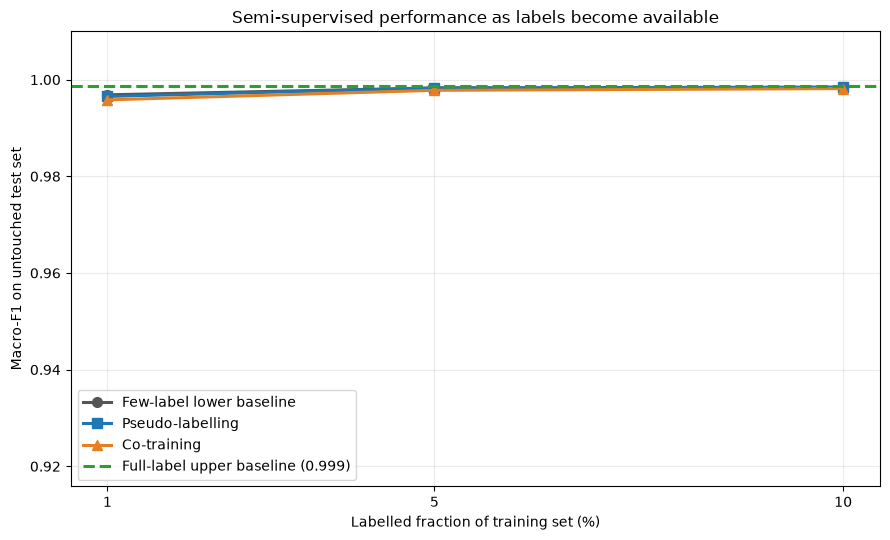

Saved Figure 1 to C:\Masters\D7084E-D7041E\Lab2\lab2_outputs\macro_f1_vs_label_budget.png


In [13]:
figure, axis = plt.subplots(figsize=(9, 5.5))
colours = {
    "Few-label lower baseline": "#555555",
    "Pseudo-labelling": "#1f77b4",
    "Co-training": "#e67e22",
}
markers = {"Few-label lower baseline": "o", "Pseudo-labelling": "s", "Co-training": "^"}

for method in ("Few-label lower baseline", "Pseudo-labelling", "Co-training"):
    subset = results[results["method"] == method].sort_values("budget_pct")
    x_values = subset["budget_pct"].to_numpy(dtype=float)
    y_values = subset["macro_f1"].to_numpy(dtype=float)
    spread = subset["macro_f1_std"].fillna(0).to_numpy(dtype=float)
    axis.plot(
        x_values, y_values, label=method, color=colours[method], marker=markers[method],
        linewidth=2.2, markersize=7,
    )
    if len(SEEDS) > 1:
        axis.fill_between(x_values, y_values - spread, y_values + spread, color=colours[method], alpha=0.15)

upper_f1 = float(np.mean([metrics["macro_f1"] for metrics in full_metrics_by_seed.values()]))
axis.axhline(
    upper_f1, color="#2ca02c", linestyle="--", linewidth=2.2,
    label=f"Full-label upper baseline ({upper_f1:.3f})",
)
axis.set(
    xlabel="Labelled fraction of training set (%)",
    ylabel="Macro-F1 on untouched test set",
    title="Semi-supervised performance as labels become available",
    xticks=[100 * budget for budget in BUDGETS],
    ylim=(max(0.0, min(results["macro_f1"].min(), upper_f1) - 0.08), 1.01),
)
axis.grid(True, alpha=0.25)
axis.legend(loc="best", frameon=True)
figure.tight_layout()
figure_path = OUTPUT_DIR / "macro_f1_vs_label_budget.png"
figure.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved Figure 1 to {figure_path}")

## 13. Automated checks and run manifest

These checks catch missing methods, invalid metrics, broken budget splits, and accidental synthetic submission. The manifest records the seed and key hyperparameters needed to reproduce the run.

In [14]:
expected_methods = {"Few-label lower baseline", "Pseudo-labelling", "Co-training"}
for budget in BUDGETS:
    observed = set(raw_results.loc[np.isclose(raw_results["budget_pct"], 100 * budget), "method"])
    if observed != expected_methods:
        raise AssertionError(f"Budget {budget} has methods {observed}, expected {expected_methods}")

metric_values = raw_results[METRIC_COLUMNS].to_numpy(dtype=float)
if not np.isfinite(metric_values).all() or ((metric_values < 0) | (metric_values > 1)).any():
    raise AssertionError("Every reported metric must be finite and between 0 and 1.")

for (seed, budget), (labelled, unlabelled) in split_cache.items():
    if np.intersect1d(labelled, unlabelled).size or len(labelled) + len(unlabelled) != len(y_train):
        raise AssertionError(f"Invalid split for seed={seed}, budget={budget}")

manifest = {
    "data_mode": ACTIVE_DATA_MODE,
    "backend": ACTIVE_BACKEND,
    "seeds": list(SEEDS),
    "budgets": list(BUDGETS),
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "ssl_rounds": SSL_ROUNDS,
    "pseudo_weight": PSEUDO_WEIGHT,
    "train_rows": len(y_train),
    "validation_rows": len(y_val),
    "test_rows": len(y_test),
    "features": X_train.shape[1],
    "cpu_threads": CPU_THREADS,
    "synthetic_results_valid_for_submission": False,
}
with open(OUTPUT_DIR / "run_manifest.json", "w", encoding="utf-8") as stream:
    json.dump(manifest, stream, indent=2)

print("ALL AUTOMATED CHECKS PASSED")
if ACTIVE_DATA_MODE == "synthetic":
    print("ACTION REQUIRED: rerun with the exact CICIDS/Lab 1 splits before submitting.")
else:
    print("Data source is non-synthetic. Confirm that TEST_CSV/NPZ test data are exactly the untouched Lab 1 test set.")

ALL AUTOMATED CHECKS PASSED
Data source is non-synthetic. Confirm that TEST_CSV/NPZ test data are exactly the untouched Lab 1 test set.


## 14. Report-ready discussion prompts

Use the generated numbers rather than making generic claims:

1. **Why labels are scarce.** Network-flow labels require expert investigation and are costly; SSL attempts to extract signal from the much larger unlabelled pool.
2. **What was done.** State the dataset, exact Lab 1 split, binary label mapping, seed(s), budgets, base learner, confidence cutoff, two SSL rounds, pseudo-label weight, and co-training feature split.
3. **Results.** Refer explicitly to Table 1 and Figure 1. At each budget, quote the macro-F1 change over the lower baseline and compare FAR and attack recall—not accuracy alone.
4. **Ablation.** Refer to Table 2. Explain how lowering the cutoff changes the number and reliability of pseudo-labels. Do not select settings from test performance.
5. **Failure cases.** If SSL loses to the lower baseline, discuss confirmation bias, poorly calibrated confidence, class imbalance, and whether the two feature views were insufficiently independent.
6. **Who did what.** Replace the line below with the actual contribution split.

**Contribution statement:** `[Name] implemented and ran the experiments; [Name] analysed results and prepared the report.`

### How to run

1. Install Python 3.10+ and run `pip install numpy pandas scikit-learn matplotlib`. Optional RTX 4060 path: also install a CUDA-capable `xgboost` build compatible with your NVIDIA driver.
2. Place the exact Lab 1 splits in `data/` using one of the layouts described in Section 2.
3. Restart the kernel and choose **Run All**. Confirm the resolved data mode is not `synthetic`.
4. Submit this notebook and the files in `lab2_outputs/` that you use in the report. For stronger averages, set `SEEDS=(42, 43, 44)` and rerun.

### References

- Lee, D.-H. (2013). *Pseudo-Label: The Simple and Efficient Semi-Supervised Learning Method for Deep Neural Networks.* ICML Workshop.
- Van Engelen, J. E., & Hoos, H. H. (2020). A survey on semi-supervised learning. *Machine Learning, 109*(2), 373-440.
- [scikit-learn semi-supervised learning guide](https://scikit-learn.org/stable/modules/semi_supervised.html)
- [scikit-learn HistGradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html)
- [XGBoost GPU support](https://xgboost.readthedocs.io/en/stable/gpu/index.html)
- [CICIDS2017](https://www.unb.ca/cic/datasets/ids-2017.html) and [CICIDS2018](https://www.unb.ca/cic/datasets/ids-2018.html)